In [ ]:
# Libraries
library(tidyverse)
library(reshape2)
library(effsize)

In [2]:
# List files
danish_annelida <- list.files("12-ExtractTaxaReads/Danish", pattern = "Eukaryota_Annelida.tsv", recursive = T, full.names = T)
danish_arthropoda <- list.files("12-ExtractTaxaReads/Danish", pattern = "Eukaryota_Arthropoda.tsv", recursive = T, full.names = T)
danish_chordata <- list.files("12-ExtractTaxaReads/Danish", pattern = "Eukaryota_Chordata.tsv", recursive = T, full.names = T)
danish_mollusca <- list.files("12-ExtractTaxaReads/Danish", pattern = "Eukaryota_Mollusca.tsv", recursive = T, full.names = T)

exotic_annelida <- list.files("12-ExtractTaxaReads/Exotic", pattern = "Eukaryota_Annelida.tsv", recursive = T, full.names = T)
exotic_arthropoda <- list.files("12-ExtractTaxaReads/Exotic", pattern = "Eukaryota_Arthropoda.tsv", recursive = T, full.names = T)
exotic_chordata <- list.files("12-ExtractTaxaReads/Exotic", pattern = "Eukaryota_Chordata.tsv", recursive = T, full.names = T)
exotic_mollusca <- list.files("12-ExtractTaxaReads/Exotic", pattern = "Eukaryota_Mollusca.tsv", recursive = T, full.names = T)

# Danish
danish <- c(danish_annelida, danish_arthropoda, danish_chordata, danish_mollusca)
exotic <- c(exotic_annelida, exotic_arthropoda, exotic_chordata, exotic_mollusca)

In [ ]:
# List files
#danish <- list.files("12-ExtractTaxaReads/Danish", pattern = ".tsv", recursive = T, full.names = T)
#exotic <- list.files("12-ExtractTaxaReads/Exotic", pattern = ".tsv", recursive = T, full.names = T)

In [ ]:
# Avoid general files
#danish <- unlist(lapply(danish, function(x) if (!basename(x) %in% c("Eukaryota_Annelida.tsv","Eukaryota_Arthropoda.tsv","Eukaryota_Chordata.tsv","Eukaryota_Mollusca.tsv")) {x}))
#exotic <- unlist(lapply(exotic, function(x) if (!basename(x) %in% c("Eukaryota_Annelida.tsv","Eukaryota_Arthropoda.tsv","Eukaryota_Chordata.tsv","Eukaryota_Mollusca.tsv")) {x}))

In [3]:
# Read data: danish (~3 min)
danish <- lapply(danish, function(x) read.table(x, header=T) %>%
         mutate(category = str_split_i(x, "/", 2),
                sample = str_split_i(x, "/", 3),
                phylum = str_split_i(str_replace(str_split_i(x, "/", 4), ".tsv", ""), "_", 2))
)

In [4]:
# Read data: exotic
exotic <- lapply(exotic, function(x) read.table(x, header=T) %>%
                   mutate(category = str_split_i(x, "/", 2),
                          sample = str_split_i(x, "/", 3),
                          phylum = str_split_i(str_replace(str_split_i(x, "/", 4), ".tsv", ""), "_", 2))
)

In [5]:
# Reduce data (~4 min)
danish <- Reduce(function(...) rbind(...), danish)
exotic <- Reduce(function(...) rbind(...), exotic)

In [6]:
dim(danish)
dim(exotic)

[1] 26715909       21

[1] 318499     21

In [7]:
# Merge data
df <- rbind(danish, exotic)

In [8]:
# Rename samples
df <- df %>%
  mutate(sample = recode(sample, 
                         "GP_1" = "EN0.2A", "GP_2" = "EN0.2B", "GP_3" = "EN0.2C",
                         "A0_2" = "OP0.2A", "B0_2" = "OP0.2B", "C0_2" = "OP0.2C",
                         "A1_2" = "OP1.2A", "B1_2" = "OP1.2B", "C1_2" = "OP1.2C",
                         "A5_0" = "OP5.0A", "B5_0" = "OP5.0B", "C5_0" = "OP5.0C",
                         "A8_0" = "OP8.0A", "B8_0" = "OP8.0B", "C8_0" = "OP8.0C"),
				 pore = recode(sample, 
                         "EN0.2A" = "EN0.2", "EN0.2B" = "EN0.2", "EN0.2C" = "EN0.2",
                         "OP0.2A" = "OP0.2", "OP0.2B" = "OP0.2", "OP0.2C" = "OP0.2",
                         "OP1.2A" = "OP1.2", "OP1.2B" = "OP1.2", "OP1.2C" = "OP1.2",
                         "OP5.0A" = "OP5.0", "OP5.0B" = "OP5.0", "OP5.0C" = "OP5.0",
                         "OP8.0A" = "OP8.0", "OP8.0B" = "OP8.0", "OP8.0C" = "OP8.0"),
				 label = recode(phylum, "Chordata" = "Actinopterygii",
				                        "Mollusca" = "Bivalvia",
																"Annelida" = "Polychaeta",
																"Arthropoda" = "Malacostraca"))

In [9]:
# Free memory
rm(danish)
rm(exotic)

---------

*Divide clear Danish and Exotic reads from multiple hits*

In [10]:
# Number of reads
df %>% select(qseqid, sample) %>% unique() %>% group_by(sample) %>% summarise(nreads = n())

sample,nreads
<chr>,<int>
EN0.2A,1967
EN0.2B,2288
EN0.2C,1623
OP0.2A,1836
OP0.2B,1196
OP0.2C,1285
OP1.2A,3830
OP1.2B,3606
OP1.2C,2915


In [56]:
# Divide between clear and ambiguous reads
mix_hits <- df %>% select(qseqid, sample, category, label) %>% mutate(value = 1) %>% group_by(qseqid, sample, category, label) %>% summarise(nhits = sum(value)) %>% pivot_wider(id_cols = c(qseqid, sample, label), values_from = nhits, names_from = category)


single_hits_reads <- mix_hits %>% filter(is.na(Danish) | is.na(Exotic))
multi_hits_reads <- mix_hits %>% drop_na()

`summarise()` has grouped output by 'qseqid', 'sample', 'category'. You can
override using the `.groups` argument.


In [79]:
multi_hits_reads %>% filter(!is.na(Exotic)) %>% group_by(sample, label) %>% summarise(count = n()) %>% pivot_wider(id_cols = label, names_from = sample, values_from = count)

`summarise()` has grouped output by 'sample'. You can override using the
`.groups` argument.


label,EN0.2A,EN0.2B,EN0.2C,OP0.2A,OP0.2B,OP0.2C,OP1.2A,OP1.2B,OP1.2C,OP5.0A,OP5.0B,OP5.0C,OP8.0A,OP8.0B,OP8.0C
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
Actinopterygii,85,110,57,73,46,58,212,219,137,290,226,166,419,316,232
Bivalvia,65,66,83,35,52,70,215,158,242,360,265,511,502,367,637
Polychaeta,1,1,10,NA,1,1,4,4,5,2,4,4,4,5,53
Malacostraca,NA,NA,NA,NA,NA,NA,NA,1,NA,NA,NA,1,5,1,1


In [80]:
nreads <- read.table(text="
label	category	EN0.2A	EN0.2B	EN0.2C	OP0.2A	OP0.2B	OP0.2C	OP1.2A	OP1.2B	OP1.2C	OP5.0A	OP5.0B	OP5.0C	OP8.0A	OP8.0B	OP8.0C
Actinopterygii	danish	663	964	258	1010	395	442	1913	2033	491	1564	2019	1107	3086	2797	1471
Bivalvia	danish	338	332	420	212	229	317	1070	697	1357	2077	1713	3607	3396	1888	3579
Malacostraca	danish	26	37	29	8	13	19	59	51	60	59	51	85	111	76	83
Polychaeta	danish	72	68	105	24	25	50	155	139	201	148	137	264	234	248	549
Actinopterygii	exotic	679	677	607	452	436	317	310	383	365	447	399	631	688	723	730
Bivalvia	exotic	22	25	25	9	3	14	48	45	66	31	55	59	67	67	135
Malacostraca	exotic	83	80	97	33	22	39	7	7	157	8	3	65	7	5	55
Polychaeta	exotic	0	0	0	0	0	1	0	1	0	2	3	1	4	1	6
Actinopterygii	ambiguous	85	110	57	73	46	58	212	219	137	290	226	166	419	316	232
Bivalvia	ambiguous	65	66	83	35	52	70	215	158	242	360	265	511	502	367	637
Malacostraca	ambiguous	0	0	0	0	0	0	0	1	0	0	0	1	5	1	1
Polychaeta	ambiguous	1	1	10	0	1	1	4	4	5	2	4	4	4	5	53
", header=TRUE)

head(nreads)

,label,category,EN0.2A,EN0.2B,EN0.2C,OP0.2A,OP0.2B,OP0.2C,OP1.2A,OP1.2B,OP1.2C,OP5.0A,OP5.0B,OP5.0C,OP8.0A,OP8.0B,OP8.0C
,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,Actinopterygii,danish,663,964,258,1010,395,442,1913,2033,491,1564,2019,1107,3086,2797,1471
2,Bivalvia,danish,338,332,420,212,229,317,1070,697,1357,2077,1713,3607,3396,1888,3579
3,Malacostraca,danish,26,37,29,8,13,19,59,51,60,59,51,85,111,76,83
4,Polychaeta,danish,72,68,105,24,25,50,155,139,201,148,137,264,234,248,549
5,Actinopterygii,exotic,679,677,607,452,436,317,310,383,365,447,399,631,688,723,730
6,Bivalvia,exotic,22,25,25,9,3,14,48,45,66,31,55,59,67,67,135


In [109]:
# Plot
melt_nreads <- melt(nreads) %>% mutate(pore = sub("[A-C]","",variable))
melt_nreads$category <- factor(melt_nreads$category, levels = c("danish", "exotic","ambiguous"))

p <- melt_nreads %>% ggplot() + geom_boxplot(aes(x=pore, y=value, color=category)) +
scale_color_manual(values = c('darkred','grey25','grey75')) +
labs(x="", y="No. of reads", color="Category") +
facet_grid(label~pore, scales="free") +
theme_bw(base_size = 12) %+replace% theme(legend.position = "top")

png(file="12-ExtractTaxaReads/num_reads.png", width = 1400, height = 1600, res=300)
p
dev.off()

Using label, category as id variables



png 
  2

Using label, category as id variables



label,correlation
<chr>,<dbl>
Actinopterygii,22.35835
Bivalvia,79.55871
Malacostraca,-15.47037
Polychaeta,77.38608


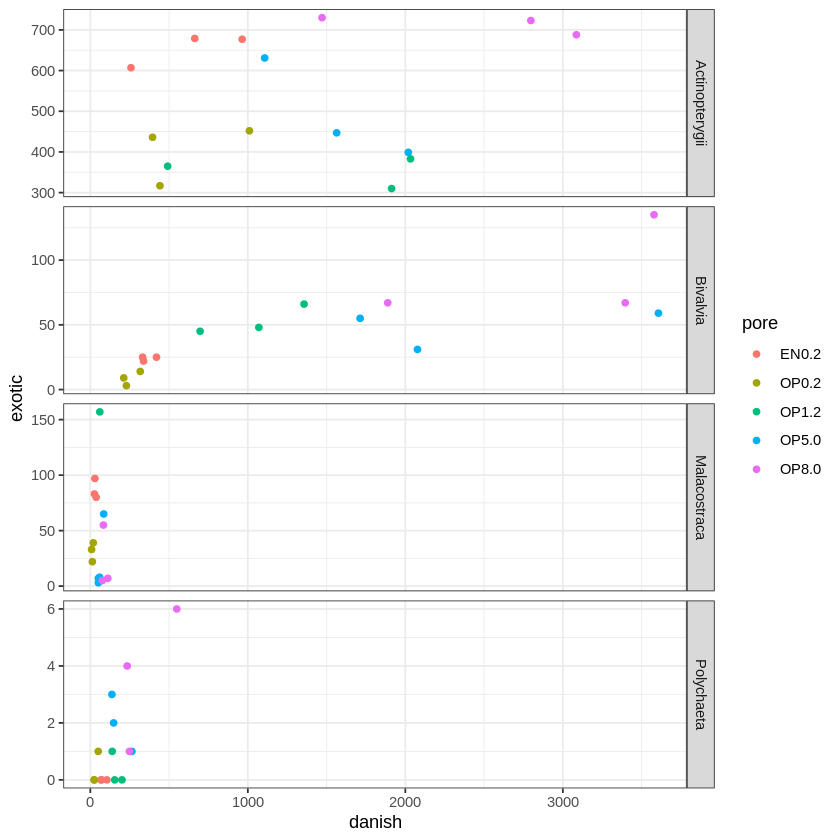

In [141]:
# Plot and Correlation
d_vs_e <- melt(nreads) %>% filter(category != "ambiguous") %>% pivot_wider(id_cols = c(label, variable), names_from = category, values_from = value) %>% mutate(pore = sub("[A-C]","",variable))

d_vs_e %>% group_by(label) %>% summarise(correlation = cor(danish, exotic, method = "pearson", use = "complete.obs")*100)

d_vs_e %>% ggplot() + geom_point(aes(x=danish, y=exotic, color=pore)) + facet_grid(label~., scales="free") +
theme_bw()

*Test hits*

In [157]:
# Clean dataset
dfclean <- df[df$qseqid %in% single_hits_reads$qseqid,]

In [162]:
# Variables
samples <- c("EN0.2A","EN0.2B","EN0.2C","OP0.2A","OP0.2B","OP0.2C","OP1.2A","OP1.2B","OP1.2C","OP5.0A","OP5.0B","OP5.0C","OP8.0A","OP8.0B","OP8.0C")
clades <- c("Polychaeta","Malacostraca","Bivalvia","Actinopterygii")

In [ ]:
# Wilcoxon test for Danish larger than Exotic -> Perc. of identity (~3 min)
# Store results
res <- list()
# Loop samples
for (s in samples) {
	# Report
	message(paste("Processing:", s ,"..."))
	# Loop clades
	for (c in clades) {
		sub <- subset(dfclean, sample == s & label == c)
		# Check if comparison is possible
		if ("Danish" %in% unique(sub$category) & "Exotic" %in% unique(sub$category)) {
			# Categories to factor
			sub$category <- factor(sub$category, levels = c("Danish","Exotic"))
			# Compute count and percentage
			cs <- table(sub$category)
			ms <- tapply(sub$pident, sub$category, mean)
			# Wilcoxon test
			wx <- wilcox.test(pident ~ category, data = sub, alternative = "greater")
			# Cliff's delta (Effect size)
			cld <- cliff.delta(pident ~ category, data = sub)
			# Append results
			res[[length(res)+1]] <- c(s, c, cs[[1]], cs[[2]], ms[[1]], ms[[2]], cld$estimate, wx$statistic[[1]], wx$p.value)
		}
	}
}

# Wilcoxon dataframe
df_wx_pide <- data.frame(do.call(rbind, res))
colnames(df_wx_pide) <- c("sample","clade","danish_entries","exotic_entries","danish_mean","exotic_mean", "cliffs_delta","statistic","pvalue")
df_wx_pide$adj_pvalue <- p.adjust(df_wx_pide$pvalue, method = "BH")

# Save results
write.table(df_wx_pide, "12-ExtractTaxaReads/pident_wilcox_cliff.tsv", sep="\t", row.names = F, quote = F)

In [ ]:
# Wilcoxon test for Danish larger than Exotic -> Alignment length (~2 min)
# Store results
res <- list()
# Loop samples
for (s in samples) {
	# Report
	message(paste("Processing:", s ,"..."))
	# Loop clades
	for (c in clades) {
		sub <- subset(dfclean, sample == s & label == c)
		# Check if comparison is possible
		if ("Danish" %in% unique(sub$category) & "Exotic" %in% unique(sub$category)) {
			# Categories to factor
			sub$category <- factor(sub$category, levels = c("Danish","Exotic"))
			# Compute count and percentage
			cs <- table(sub$category)
			ms <- tapply(sub$length, sub$category, mean)
			# Wilcoxon test
			wx <- wilcox.test(length ~ category, data = sub, alternative = "greater")
			# Cliff's delta (Effect size)
			cld <- cliff.delta(length ~ category, data = sub)
			# Append results
			res[[length(res)+1]] <- c(s, c, cs[[1]], cs[[2]], ms[[1]], ms[[2]], cld$estimate, wx$statistic[[1]], wx$p.value)
		}
	}
}

# Wilcoxon dataframe
df_wx_alen <- data.frame(do.call(rbind, res))
colnames(df_wx_alen) <- c("sample","clade","danish_entries","exotic_entries","danish_mean","exotic_mean", "cliffs_delta","statistic","pvalue")
df_wx_alen$adj_pvalue <- p.adjust(df_wx_alen$pvalue, method = "BH")

# Save results
write.table(df_wx_alen, "12-ExtractTaxaReads/alnlen_wilcox_cliff.tsv", sep="\t", row.names = F, quote = F)

In [ ]:
# Wilcoxon test for Danish larger than Exotic -> Mismatches (~2 min)
# Store results
res <- list()
# Loop samples
for (s in samples) {
	# Report
	message(paste("Processing:", s ,"..."))
	# Loop clades
	for (c in clades) {
		sub <- subset(dfclean, sample == s & label == c)
		# Check if comparison is possible
		if ("Danish" %in% unique(sub$category) & "Exotic" %in% unique(sub$category)) {
			# Categories to factor
			sub$category <- factor(sub$category, levels = c("Danish","Exotic"))
			# Compute count and percentage
			cs <- table(sub$category)
			ms <- tapply(sub$mismatch, sub$category, mean)
			# Wilcoxon test
			wx <- wilcox.test(mismatch ~ category, data = sub, alternative = "less")
			# Cliff's delta (Effect size)
			cld <- cliff.delta(mismatch ~ category, data = sub)
			# Append results
			res[[length(res)+1]] <- c(s, c, cs[[1]], cs[[2]], ms[[1]], ms[[2]], cld$estimate, wx$statistic[[1]], wx$p.value)
		}
	}
}

# Wilcoxon dataframe
df_wx_mism <- data.frame(do.call(rbind, res))
colnames(df_wx_mism) <- c("sample","clade","danish_entries","exotic_entries","danish_mean","exotic_mean", "cliffs_delta","statistic","pvalue")
df_wx_mism$adj_pvalue <- p.adjust(df_wx_mism$pvalue, method = "BH")

# Save results
write.table(df_wx_mism, "12-ExtractTaxaReads/mismatch_wilcox_cliff.tsv", sep="\t", row.names = F, quote = F)

In [174]:
df_wx_pide %>% filter(adj_pvalue < 0.05 & as.numeric(cliffs_delta) > 0.33 & as.numeric(exotic_entries) > 100)
df_wx_alen %>% filter(adj_pvalue < 0.05 & as.numeric(cliffs_delta) > 0.33 & as.numeric(exotic_entries) > 100)
df_wx_mism %>% filter(adj_pvalue < 0.05 & as.numeric(cliffs_delta) > 0.33 & as.numeric(exotic_entries) > 100)

sample,clade,danish_entries,exotic_entries,danish_mean,exotic_mean,cliffs_delta,statistic,pvalue,adj_pvalue
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
EN0.2A,Bivalvia,2440,242,97.0508545081967,95.2087024793388,0.347737433952039,397906,1.52490682449453e-19,6.568829e-19
EN0.2A,Actinopterygii,633444,2973,93.0593462594957,91.7658812647158,0.377702654041313,1297264804,1.10425027121639e-277,6.183802e-276
OP0.2A,Bivalvia,2342,123,98.0341686592656,95.1963089430894,0.583869668756466,228129.5,1.01271903296004e-31,8.101752e-31
OP0.2A,Actinopterygii,306417,2256,92.6379534392674,91.5245385638298,0.385210975531259,478782072,4.10219820520159e-219,1.148615e-217
OP0.2B,Actinopterygii,147300,1204,93.4344980515954,92.0315523255814,0.353086904254431,119984440,1.91360192838381e-99,3.572057e-98
OP0.2C,Bivalvia,3141,266,97.7006170009551,96.4145601503759,0.384321596732998,578304.5,2.23391635634504e-26,1.389992e-25


sample,clade,danish_entries,exotic_entries,danish_mean,exotic_mean,cliffs_delta,statistic,pvalue,adj_pvalue
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
EN0.2A,Bivalvia,2440,242,231.68606557377,217.028925619835,0.333374542744886,393665.5,3.34299397719849e-18,3.120128e-17
EN0.2B,Bivalvia,1792,330,225.47265625,202.509090909091,0.388959347943723,410687.5,1.11412875561501e-29,2.079707e-28
OP5.0B,Actinopterygii,771779,2781,195.296753345193,154.378640776699,0.405618744182766,1508451983.5,9.55139295837019e-300,5.348780e-298


sample,clade,danish_entries,exotic_entries,danish_mean,exotic_mean,cliffs_delta,statistic,pvalue,adj_pvalue
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
